In [67]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from subperiod_eval import subperiod_table

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

In [68]:
# ── Change these to control which configs appear ────────────────────────────
AB_DIR = Path('../data/backtest/xgboost_ab')

CFGS = {
    'A_decile_ew':         ('A — Decile EW (baseline)',      'steelblue',  '-'),
    'B_rankw_vw':          ('B — Rank-weight VW',            'darkorange', '--'),
    'C_rankw_vw_balanced': ('C — Rank-weight VW + balance',  'seagreen',   '-.'),
}

TC_BPS = 10   # must match the --tc flag used in ab_harness.py

# Set to False if you only want to look at a subset
SHOW_A = False
SHOW_B = True
SHOW_C = True

## 1. Load Results

In [69]:
visibility = {'A_decile_ew': SHOW_A, 'B_rankw_vw': SHOW_B, 'C_rankw_vw_balanced': SHOW_C}

dfs = {}
for cfg, (label, color, ls) in CFGS.items():
    if not visibility[cfg]:
        continue
    path = AB_DIR / f'monthly_returns_{cfg}.csv'
    if not path.exists():
        print(f'WARNING: {path.name} not found — skipping')
        continue
    df = pd.read_csv(path)
    df['eom'] = pd.to_datetime(df['eom'])
    df = df.sort_values('eom').reset_index(drop=True)
    dfs[cfg] = df
    print(f'  {cfg:<26}  {len(df):>3} months  '
          f'({df["eom"].min().date()} – {df["eom"].max().date()})')

if not dfs:
    raise FileNotFoundError(f'No CSV files found in {AB_DIR}. Run ab_harness.py first.')

  B_rankw_vw                  478 months  (1986-01-31 – 2025-10-31)
  C_rankw_vw_balanced         478 months  (1986-01-31 – 2025-10-31)


## 2. Full-Sample Performance Summary

In [70]:
def _stats(s):
    s = s.dropna()
    if len(s) < 6:
        return {}
    ann_ret = float(s.mean() * 12)
    ann_vol = float(s.std() * np.sqrt(12))
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = (1 + s).cumprod()
    max_dd  = float(((cum - cum.cummax()) / cum.cummax()).min())
    return dict(ann_ret=ann_ret, ann_vol=ann_vol, sharpe=sharpe,
                max_dd=max_dd, win_rate=float((s > 0).mean()), n_months=len(s))

rows = []
for cfg, df in dfs.items():
    label = CFGS[cfg][0]
    g  = _stats(df['qspread'])
    n  = _stats(df['net_qspread'])
    ic = df['ic_spearman'].dropna()
    icir = float(ic.mean() / ic.std() * np.sqrt(12)) if ic.std() > 0 else np.nan
    to_mean = df['turnover'].mean() if 'turnover' in df.columns else np.nan
    rows.append({
        'Config':     label,
        'Gross SR':   g.get('sharpe'),
        'Net SR':     n.get('sharpe'),
        'Gross Ret':  g.get('ann_ret'),
        'Net Ret':    n.get('ann_ret'),
        'Ann Vol':    g.get('ann_vol'),
        'Max DD':     n.get('max_dd'),
        'Win Rate':   n.get('win_rate'),
        'Mean IC':    float(ic.mean()),
        'ICIR':       icir,
        'TC Drag':    (g.get('ann_ret', np.nan) - n.get('ann_ret', np.nan)),
        'Avg TO':     to_mean,
        'N Months':   g.get('n_months'),
    })

perf = pd.DataFrame(rows).set_index('Config')

fmt = {
    'Gross SR': '{:.3f}', 'Net SR': '{:.3f}',
    'Gross Ret': '{:.2%}', 'Net Ret': '{:.2%}',
    'Ann Vol': '{:.2%}', 'Max DD': '{:.2%}',
    'Win Rate': '{:.2%}', 'Mean IC': '{:.4f}',
    'ICIR': '{:.3f}', 'TC Drag': '{:.2%}',
    'Avg TO': '{:.3f}', 'N Months': '{:.0f}',
}
# perf.style.format(fmt)

## 3. Cumulative Return Comparison

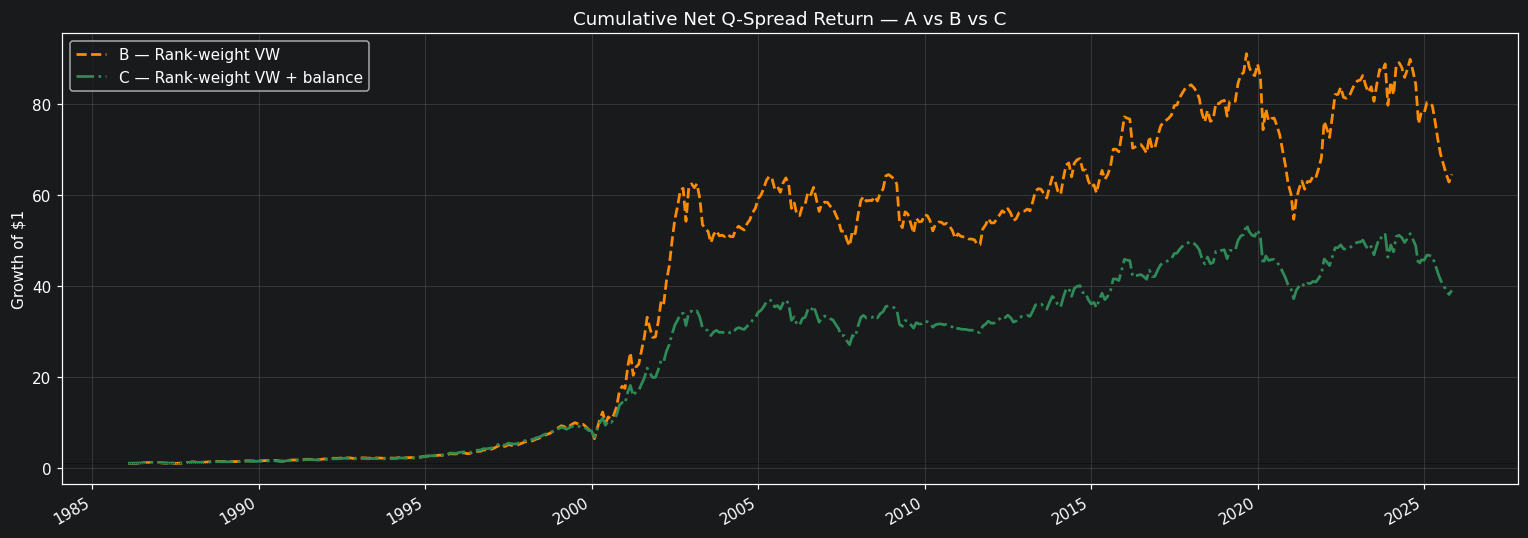

In [71]:
fig, ax = plt.subplots(figsize=(14, 5))
for cfg, df in dfs.items():
    label, color, ls = CFGS[cfg]
    cum = (1 + df['net_qspread']).cumprod()
    ax.plot(df['eom'], cum, label=label, color=color, ls=ls, lw=1.8)
ax.axhline(1, color='black', lw=0.5, ls=':')
ax.set_title('Cumulative Net Q-Spread Return — A vs B vs C')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

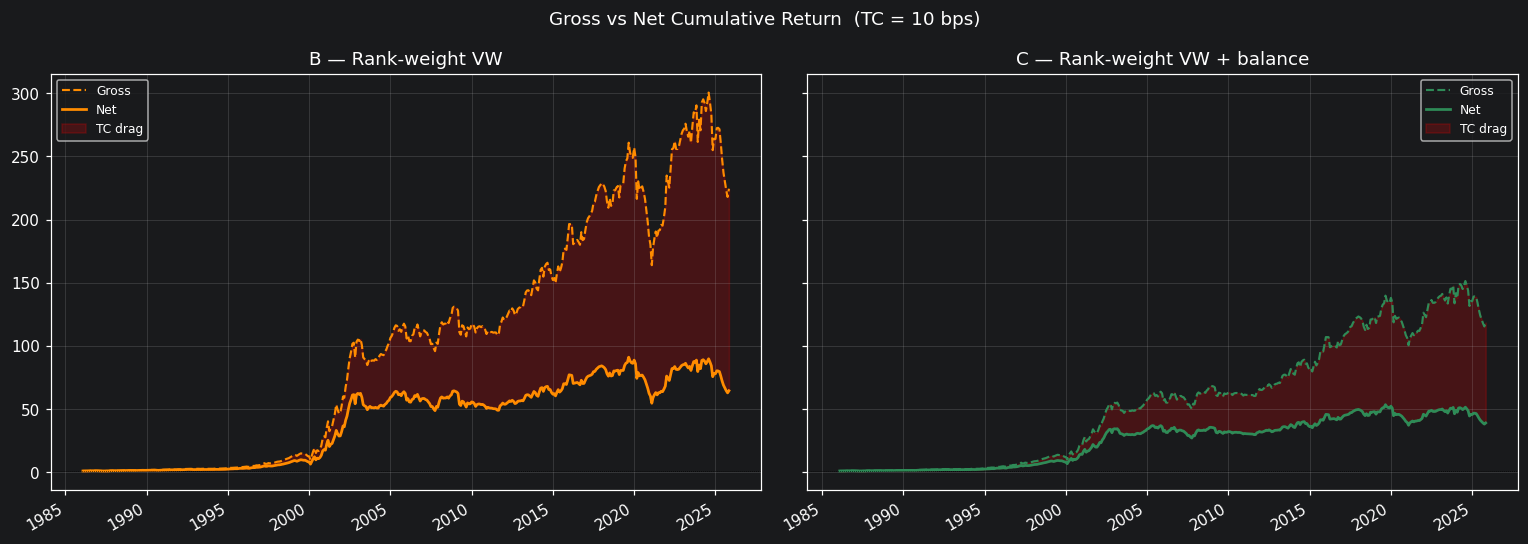

In [72]:
# Gross vs Net for each config — shows TC drag
n_cfgs = len(dfs)
fig, axes = plt.subplots(1, n_cfgs, figsize=(7 * n_cfgs, 5), sharey=True)
if n_cfgs == 1:
    axes = [axes]

for ax, (cfg, df) in zip(axes, dfs.items()):
    label, color, ls = CFGS[cfg]
    cum_gross = (1 + df['qspread']).cumprod()
    cum_net   = (1 + df['net_qspread']).cumprod()
    ax.plot(df['eom'], cum_gross, color=color, ls='--', lw=1.4, label='Gross')
    ax.plot(df['eom'], cum_net,   color=color, ls='-',  lw=1.8, label='Net')
    ax.fill_between(df['eom'], cum_gross, cum_net, alpha=0.2, color='red', label='TC drag')
    ax.axhline(1, color='black', lw=0.5, ls=':')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))

fig.suptitle(f'Gross vs Net Cumulative Return  (TC = {TC_BPS} bps)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Rolling Risk Metrics

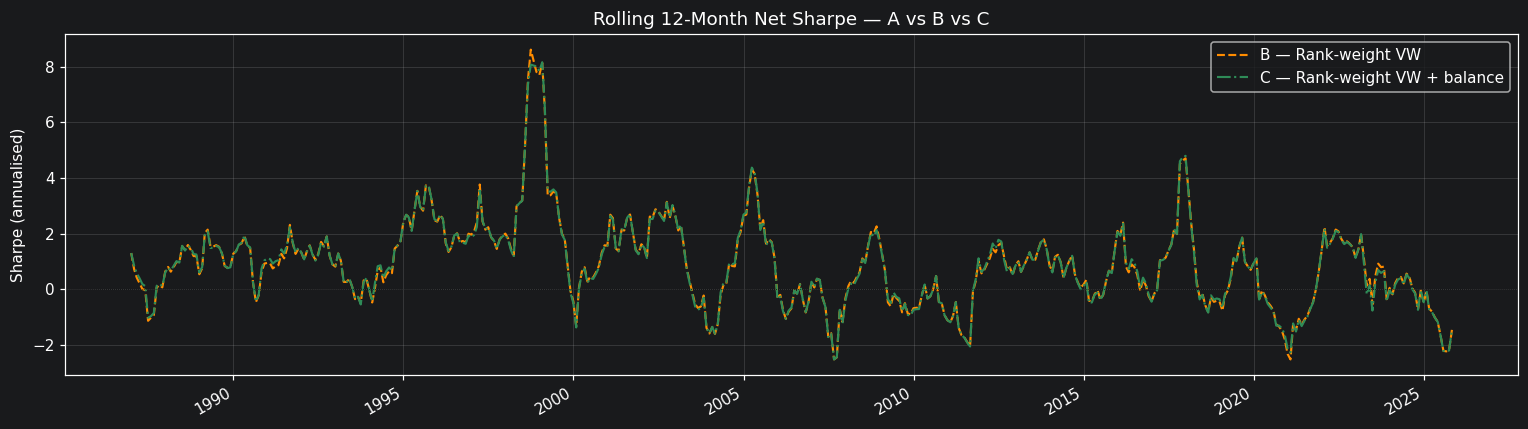

In [73]:
# Rolling 12-month Sharpe
fig, ax = plt.subplots(figsize=(14, 4))
for cfg, df in dfs.items():
    label, color, ls = CFGS[cfg]
    roll = df['net_qspread'].rolling(12)
    rs   = np.where(roll.std() > 0, roll.mean() / roll.std() * np.sqrt(12), np.nan)
    ax.plot(df['eom'], rs, label=label, color=color, ls=ls, lw=1.4)
ax.axhline(0, color='black', lw=0.5, ls=':')
ax.set_title('Rolling 12-Month Net Sharpe — A vs B vs C')
ax.set_ylabel('Sharpe (annualised)')
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

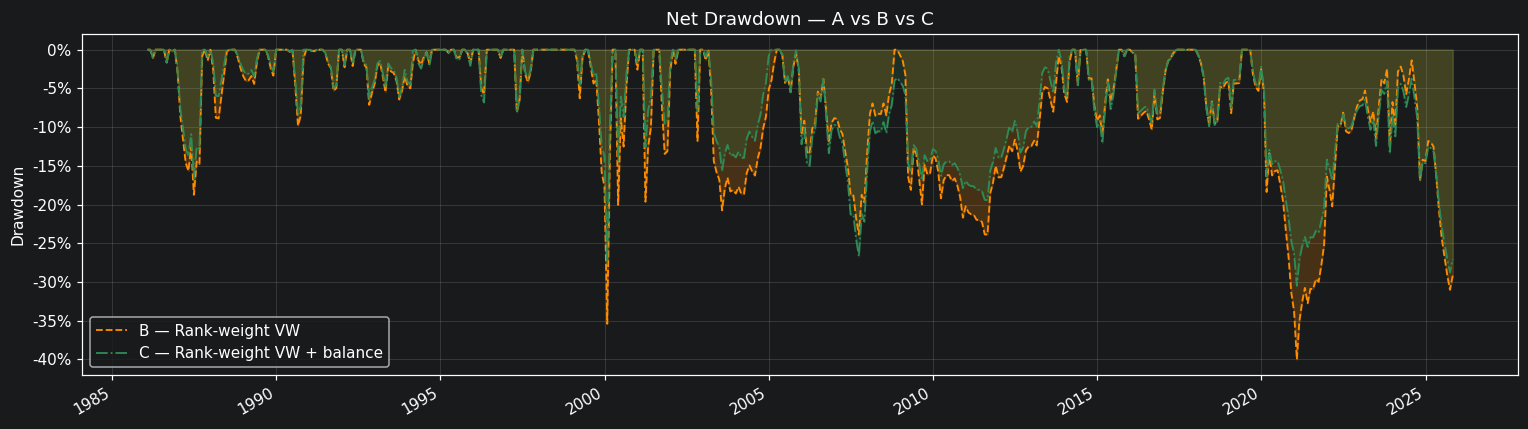

In [74]:
# Drawdown chart
def _drawdown(s):
    cum = (1 + s.dropna()).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

fig, ax = plt.subplots(figsize=(14, 4))
for cfg, df in dfs.items():
    label, color, ls = CFGS[cfg]
    dd = _drawdown(df.set_index('eom')['net_qspread'])
    ax.fill_between(dd.index, dd, 0, alpha=0.2, color=color)
    ax.plot(dd.index, dd, color=color, ls=ls, lw=1.2, label=label)
ax.set_title('Net Drawdown — A vs B vs C')
ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Information Coefficient

All three configs share the same underlying model and signal, so IC is identical across A/B/C. We show it once here.

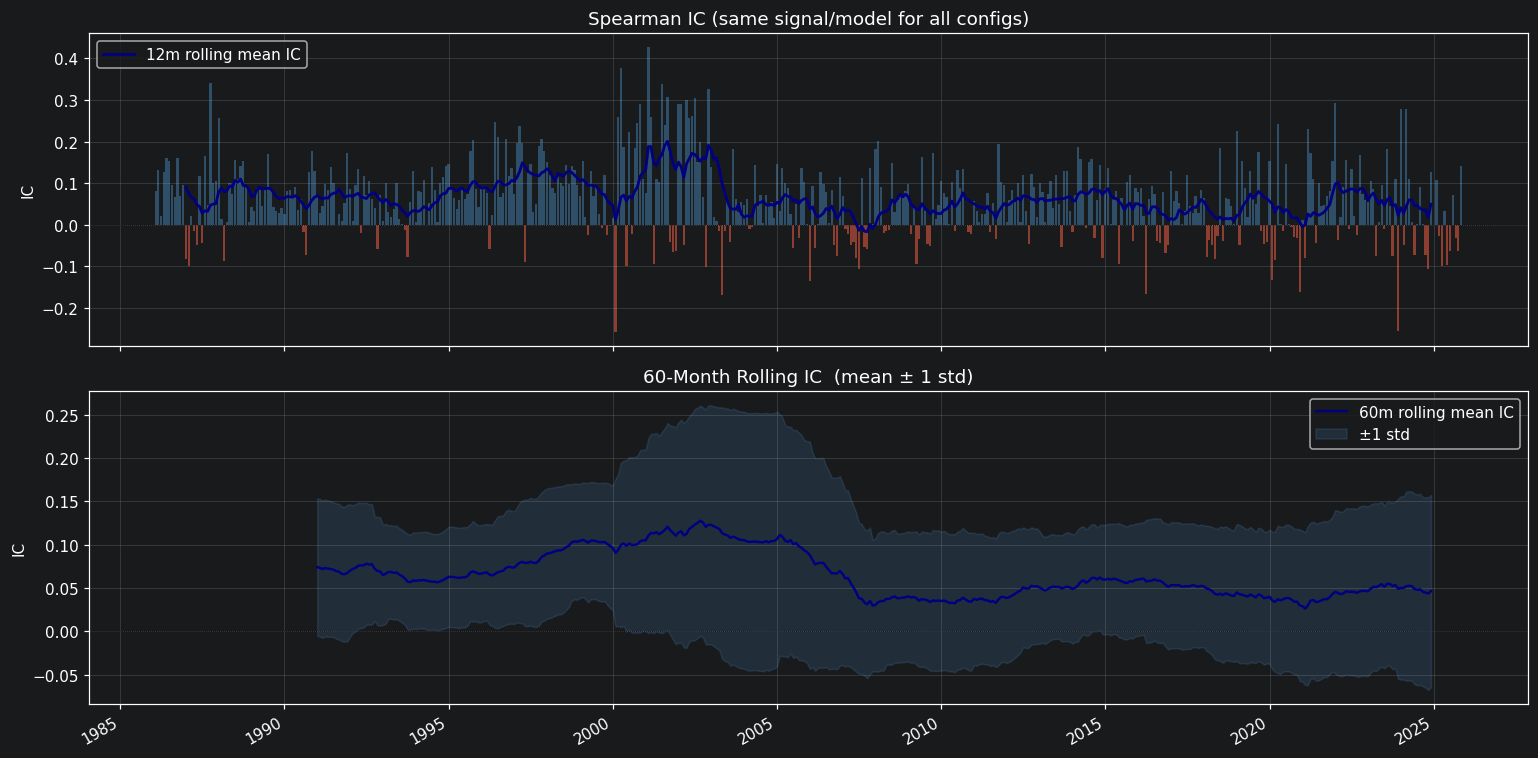

Full-sample mean IC : 0.0635
Full-sample ICIR    : 2.348
Last-60m mean IC    : 0.0427
Last-60m ICIR       : 1.360


In [75]:
first_cfg = next(iter(dfs))
df0 = dfs[first_cfg]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1: IC bar + rolling mean
ax = axes[0]
ic = df0['ic_spearman']
bar_colors = ['steelblue' if v >= 0 else 'tomato' for v in ic.fillna(0)]
ax.bar(df0['eom'], ic, width=25, color=bar_colors, alpha=0.5)
ax.plot(df0['eom'], ic.rolling(12).mean(), color='navy', lw=1.8, label='12m rolling mean IC')
ax.axhline(0, color='black', lw=0.5, ls=':')
ax.set_title('Spearman IC (same signal/model for all configs)')
ax.set_ylabel('IC')
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 2: IC vol (60m rolling)
ax = axes[1]
ic_rolling_mean = ic.rolling(60).mean()
ic_rolling_std  = ic.rolling(60).std()
ax.plot(df0['eom'], ic_rolling_mean, color='navy', lw=1.6, label='60m rolling mean IC')
ax.fill_between(df0['eom'],
                ic_rolling_mean - ic_rolling_std,
                ic_rolling_mean + ic_rolling_std,
                alpha=0.2, color='steelblue', label='±1 std')
ax.axhline(0, color='black', lw=0.5, ls=':')
ax.set_title('60-Month Rolling IC  (mean ± 1 std)')
ax.set_ylabel('IC')
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Full-sample mean IC : {ic.mean():.4f}")
print(f"Full-sample ICIR    : {ic.mean()/ic.std()*np.sqrt(12):.3f}")
print(f"Last-60m mean IC    : {ic.iloc[-60:].mean():.4f}")
print(f"Last-60m ICIR       : {ic.iloc[-60:].mean()/ic.iloc[-60:].std()*np.sqrt(12):.3f}")

## 6. Turnover

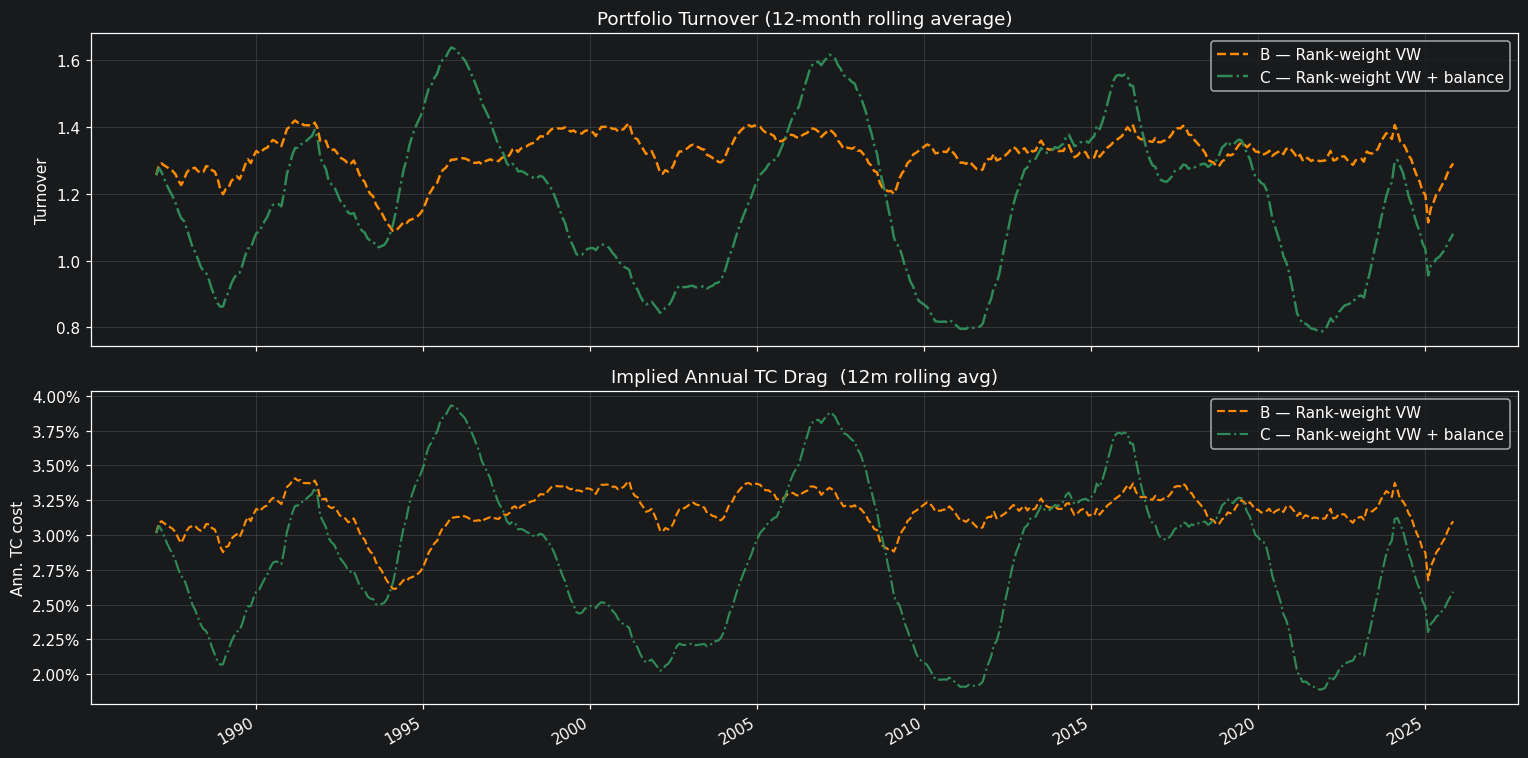


Config                                Avg TO  Ann TC drag
---------------------------------------------------------
B — Rank-weight VW                     1.315        3.16%
C — Rank-weight VW + balance           1.171        2.81%


In [76]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1: rolling average turnover
ax = axes[0]
for cfg, df in dfs.items():
    if 'turnover' not in df.columns:
        continue
    label, color, ls = CFGS[cfg]
    ax.plot(df['eom'], df['turnover'].rolling(12).mean(),
            label=f'{label}', color=color, ls=ls, lw=1.6)
ax.set_title('Portfolio Turnover (12-month rolling average)')
ax.set_ylabel('Turnover')
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 2: monthly TC drag (TC_BPS/10000 * 2 * TO)
ax = axes[1]
for cfg, df in dfs.items():
    if 'turnover' not in df.columns:
        continue
    label, color, ls = CFGS[cfg]
    tc_monthly = (TC_BPS / 10_000) * 2 * df['turnover']
    ax.plot(df['eom'], tc_monthly.rolling(12).mean() * 12,
            label=label, color=color, ls=ls, lw=1.4)
ax.set_title('Implied Annual TC Drag  (12m rolling avg)')
ax.set_ylabel('Ann. TC cost')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Config':<35} {'Avg TO':>8} {'Ann TC drag':>12}")
print('-' * 57)
for cfg, df in dfs.items():
    if 'turnover' not in df.columns:
        continue
    label = CFGS[cfg][0]
    avg_to = df['turnover'].mean()
    ann_tc = avg_to * 2 * (TC_BPS / 10_000) * 12
    print(f'{label:<35} {avg_to:>8.3f} {ann_tc:>12.2%}')

## 7. Long & Short Leg Analysis

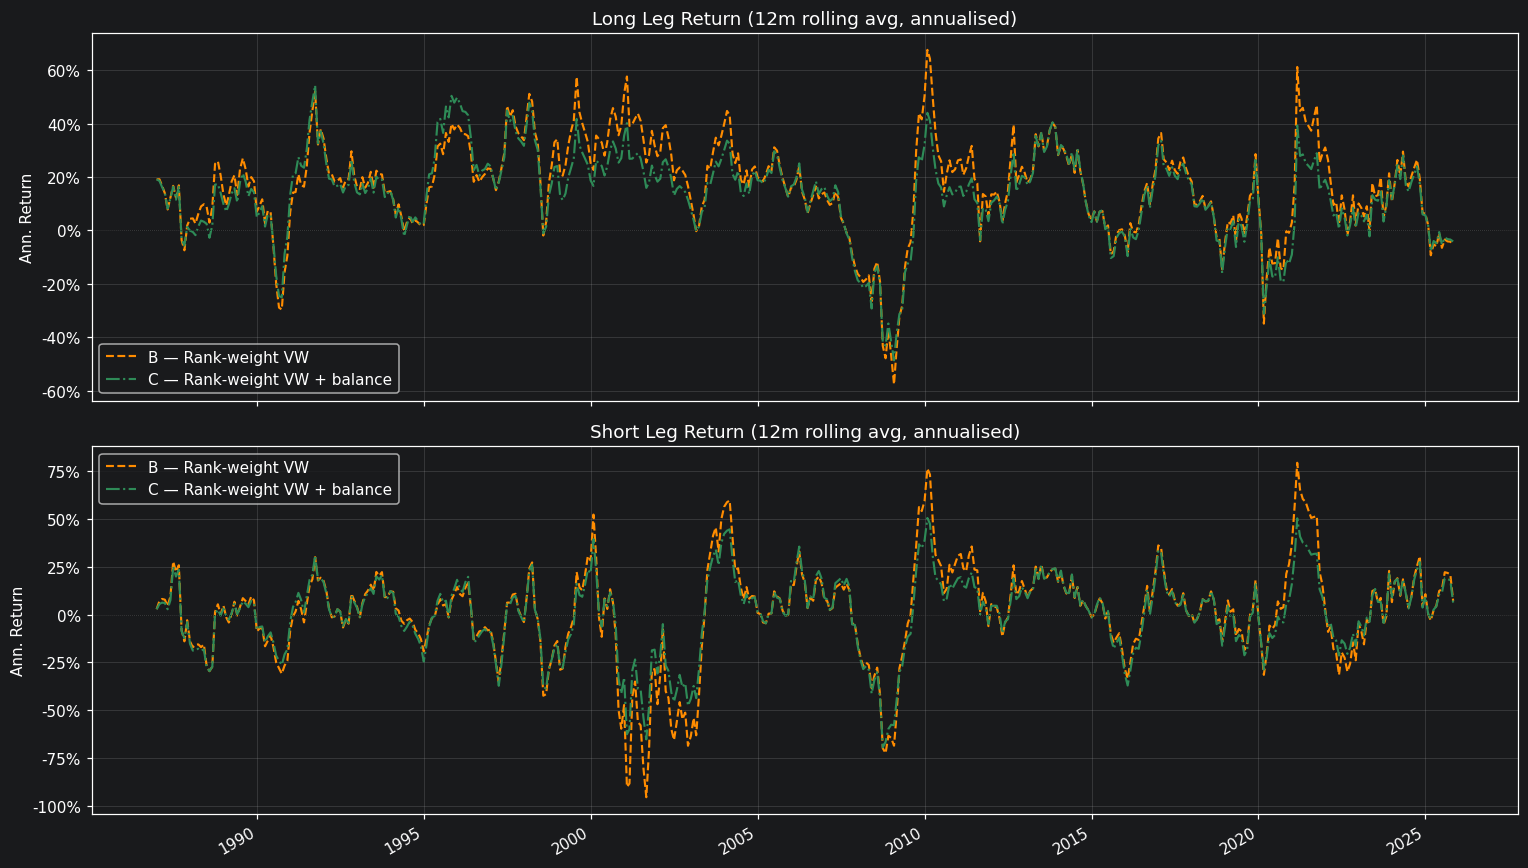


Config                                Long ann  Short ann     Spread
-------------------------------------------------------------------
B — Rank-weight VW                      16.44%      1.24%     15.20%
C — Rank-weight VW + balance            13.50%      0.48%     13.02%


In [77]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, leg in zip(axes, ['long_ret', 'short_ret']):
    for cfg, df in dfs.items():
        label, color, ls = CFGS[cfg]
        ann_roll = df[leg].rolling(12).mean() * 12
        ax.plot(df['eom'], ann_roll, label=label, color=color, ls=ls, lw=1.4)
    ax.axhline(0, color='black', lw=0.5, ls=':')
    side = 'Long' if leg == 'long_ret' else 'Short'
    ax.set_title(f'{side} Leg Return (12m rolling avg, annualised)')
    ax.set_ylabel('Ann. Return')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend()
    ax.grid(True, alpha=0.25)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Long/short contribution table
print(f"\n{'Config':<35} {'Long ann':>10} {'Short ann':>10} {'Spread':>10}")
print('-' * 67)
for cfg, df in dfs.items():
    label = CFGS[cfg][0]
    l = df['long_ret'].mean() * 12
    s = df['short_ret'].mean() * 12
    print(f'{label:<35} {l:>10.2%} {s:>10.2%} {l-s:>10.2%}')

## 8. Universe & Portfolio Size

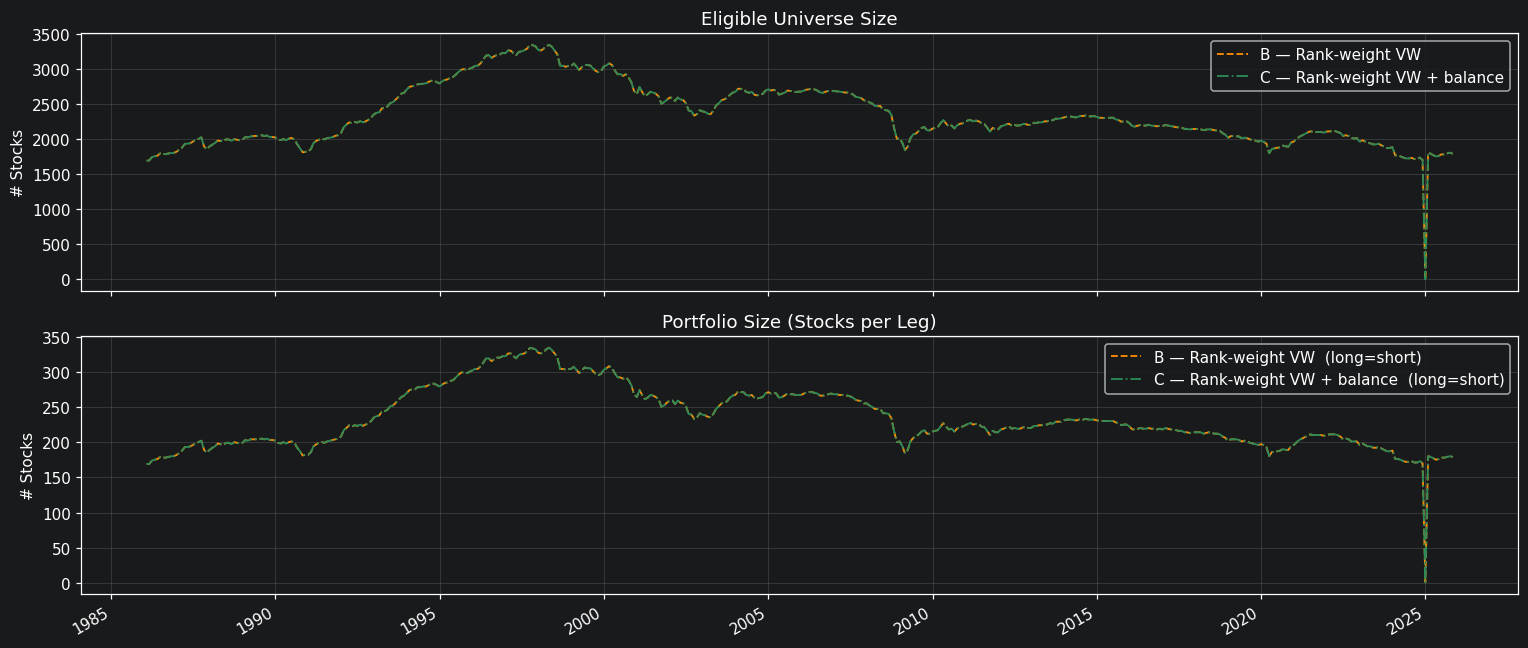

In [78]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
for cfg, df in dfs.items():
    label, color, ls = CFGS[cfg]
    ax.plot(df['eom'], df['n_universe'], label=label, color=color, ls=ls, lw=1.2)
ax.set_title('Eligible Universe Size')
ax.set_ylabel('# Stocks')
ax.legend()
ax.grid(True, alpha=0.25)

ax = axes[1]
for cfg, df in dfs.items():
    label, color, ls = CFGS[cfg]
    ax.plot(df['eom'], df['n_long'], label=f'{label}  (long=short)',
            color=color, ls=ls, lw=1.2)
ax.set_title('Portfolio Size (Stocks per Leg)')
ax.set_ylabel('# Stocks')
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Monthly Return Distribution

/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_25188/1022274221.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_decade, labels=decades, patch_artist=True,
/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_25188/1022274221.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_decade, labels=decades, patch_artist=True,


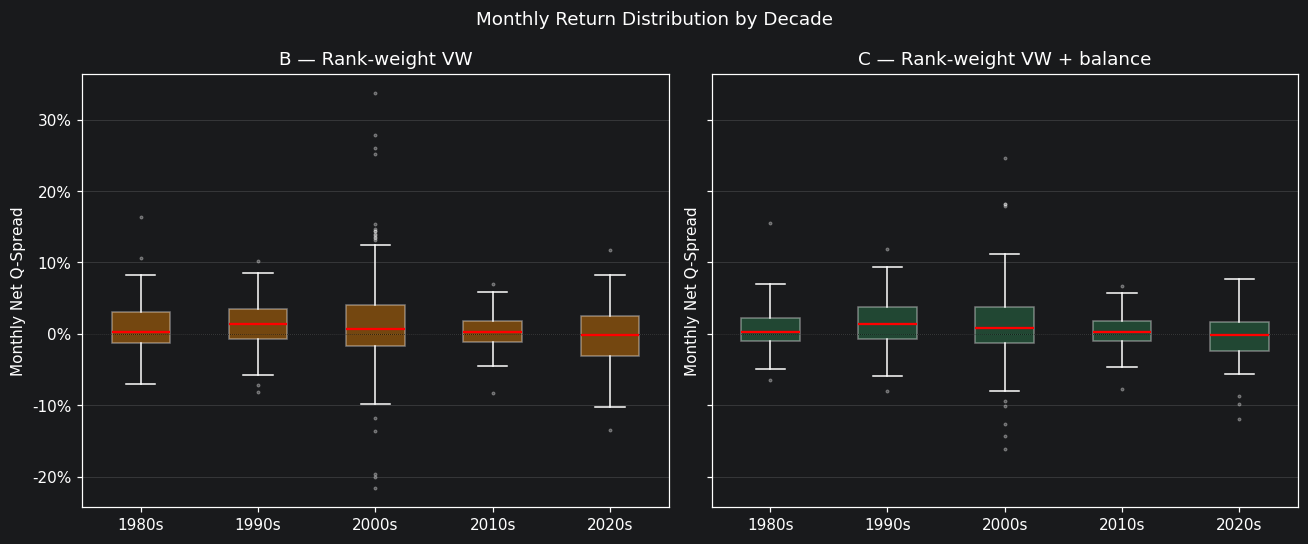

In [60]:
# Box plot by decade
n_cfgs = len(dfs)
fig, axes = plt.subplots(1, n_cfgs, figsize=(6 * n_cfgs, 5), sharey=True)
if n_cfgs == 1:
    axes = [axes]

for ax, (cfg, df) in zip(axes, dfs.items()):
    label, color, ls = CFGS[cfg]
    df = df.copy()
    df['decade'] = (df['eom'].dt.year // 10 * 10).astype(str) + 's'
    decades = sorted(df['decade'].unique())
    data_by_decade = [df[df['decade'] == d]['net_qspread'].dropna().values for d in decades]
    bp = ax.boxplot(data_by_decade, labels=decades, patch_artist=True,
                    medianprops=dict(color='red', lw=1.5),
                    flierprops=dict(marker='.', ms=3, alpha=0.4))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.4)
    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.set_title(label)
    ax.set_ylabel('Monthly Net Q-Spread')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(True, alpha=0.25, axis='y')

fig.suptitle('Monthly Return Distribution by Decade', fontsize=12)
plt.tight_layout()
plt.show()

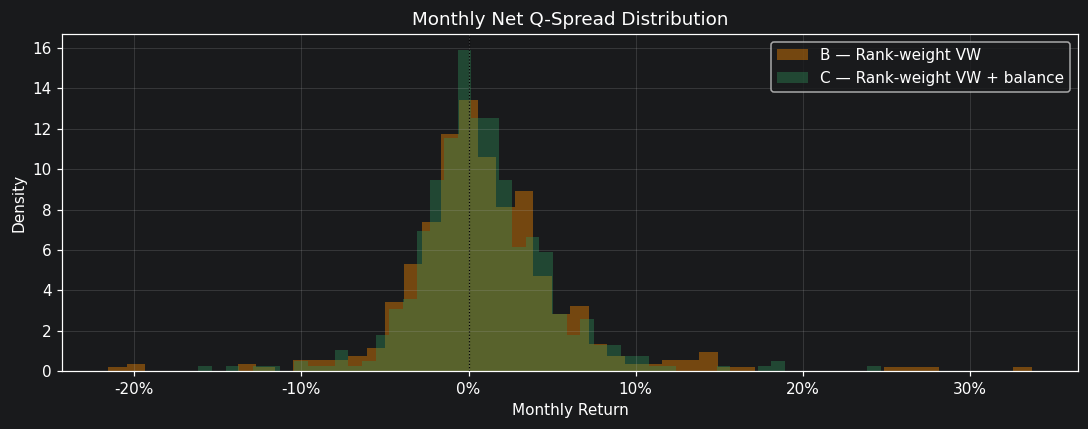


Config                                  Skew     Kurt      Min      Max
---------------------------------------------------------------------
B — Rank-weight VW                     1.053    8.301  -21.54%   33.69%
C — Rank-weight VW + balance           0.691    5.099  -16.16%   24.64%


In [61]:
# Overlapping histograms
fig, ax = plt.subplots(figsize=(10, 4))
for cfg, df in dfs.items():
    label, color, ls = CFGS[cfg]
    ax.hist(df['net_qspread'].dropna(), bins=50, alpha=0.4, color=color, label=label, density=True)
ax.axvline(0, color='black', lw=0.8, ls=':')
ax.set_title('Monthly Net Q-Spread Distribution')
ax.set_xlabel('Monthly Return')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\n{'Config':<35} {'Skew':>8} {'Kurt':>8} {'Min':>8} {'Max':>8}")
print('-' * 69)
for cfg, df in dfs.items():
    label = CFGS[cfg][0]
    s = df['net_qspread'].dropna()
    print(f"{label:<35} {s.skew():>8.3f} {s.kurtosis():>8.3f} {s.min():>8.2%} {s.max():>8.2%}")

## 10. Year-by-Year Net Sharpe

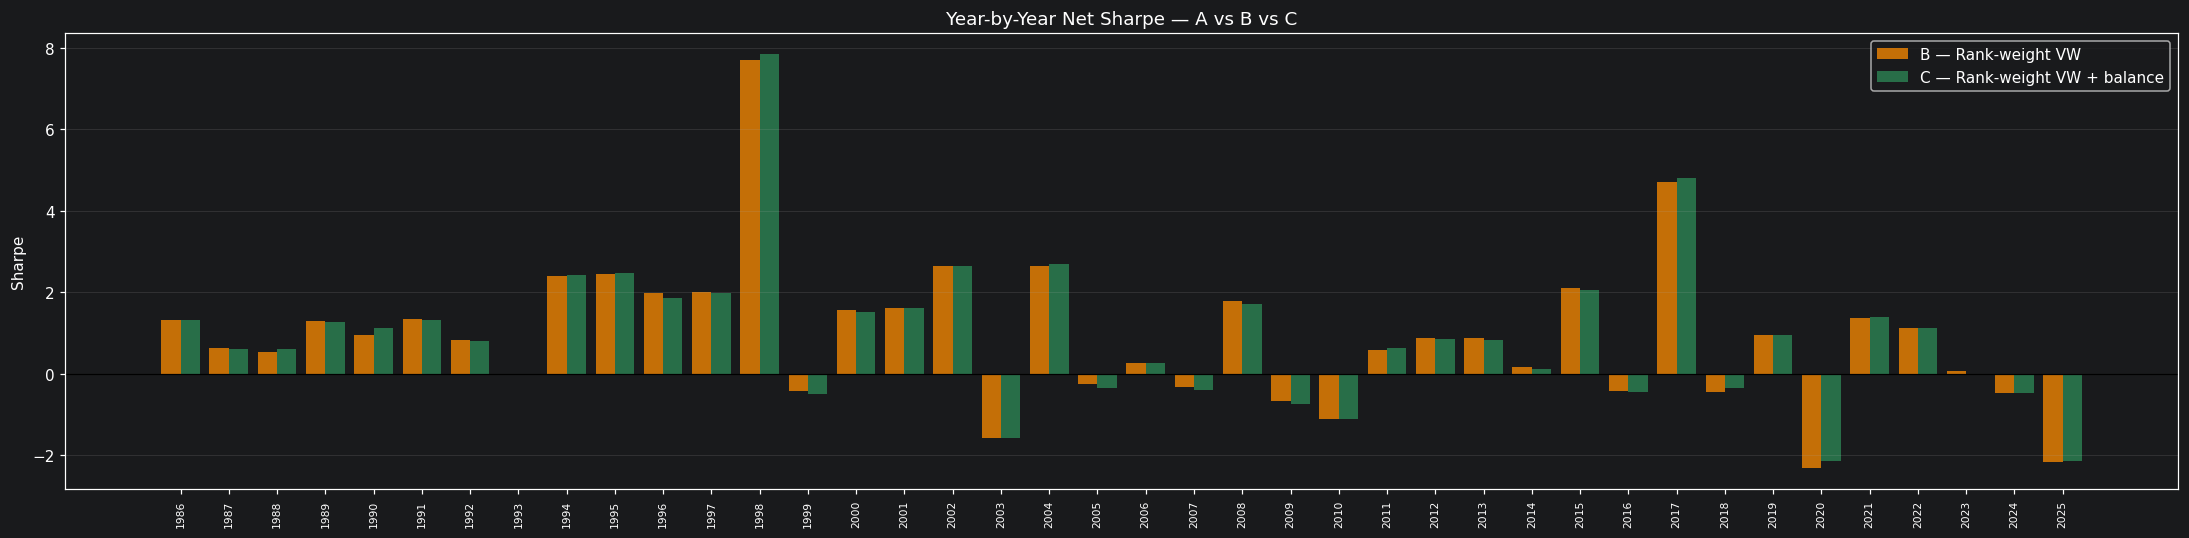

In [62]:
all_years_sets = [set(df['eom'].dt.year) for df in dfs.values()]
years = sorted(set.union(*all_years_sets))
n_cfgs = len(dfs)
bar_width = 0.8 / n_cfgs

fig, ax = plt.subplots(figsize=(max(14, len(years) * 0.5), 5))
for i, (cfg, df) in enumerate(dfs.items()):
    label, color, ls = CFGS[cfg]
    df2 = df.copy()
    df2['year'] = df2['eom'].dt.year
    yr_sharpe = df2.groupby('year')['net_qspread'].apply(
        lambda s: float(s.mean() / s.std() * np.sqrt(12)) if s.dropna().std() > 0 else np.nan
    )
    x_pos = np.array([years.index(y) for y in yr_sharpe.index])
    offset = i * bar_width - (n_cfgs - 1) * bar_width / 2
    ax.bar(x_pos + offset, yr_sharpe.values, width=bar_width,
           color=color, alpha=0.75, label=label)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=90, fontsize=7)
ax.set_title('Year-by-Year Net Sharpe — A vs B vs C')
ax.set_ylabel('Sharpe')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

## 11. Correlation Between Configs

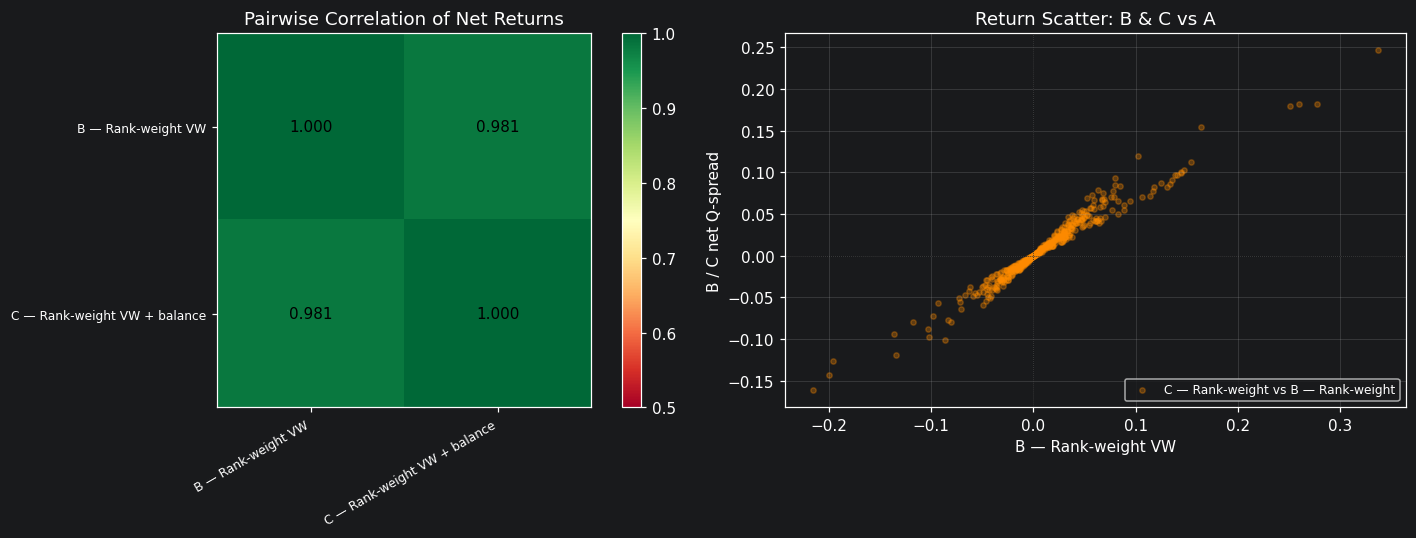


Correlation matrix (net Q-spread):
                              B — Rank-weight VW  C — Rank-weight VW + balance
B — Rank-weight VW                        1.0000                        0.9806
C — Rank-weight VW + balance              0.9806                        1.0000


In [63]:
if len(dfs) > 1:
    common_eom = sorted(set.intersection(*[set(df['eom']) for df in dfs.values()]))
    ret_df = pd.DataFrame({
        CFGS[cfg][0]: df.set_index('eom').loc[common_eom, 'net_qspread']
        for cfg, df in dfs.items()
    })
    corr = ret_df.corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Heatmap
    ax = axes[0]
    im = ax.imshow(corr.values, cmap='RdYlGn', vmin=0.5, vmax=1.0)
    ticks = range(len(corr))
    short_labels = [f'Config {c[0]}' for c in corr.columns]
    ax.set_xticks(ticks); ax.set_xticklabels(corr.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(ticks); ax.set_yticklabels(corr.index, fontsize=8)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f'{corr.iloc[i, j]:.3f}', ha='center', va='center',
                    fontsize=10, color='black')
    plt.colorbar(im, ax=ax)
    ax.set_title('Pairwise Correlation of Net Returns')

    # Scatter
    ax = axes[1]
    cols = list(ret_df.columns)
    scatter_pairs = [(cols[0], cols[1]), (cols[0], cols[2])] if len(cols) >= 3 else [(cols[0], cols[1])]
    scatter_colors = ['darkorange', 'seagreen']
    for (xc, yc), sc in zip(scatter_pairs, scatter_colors):
        ax.scatter(ret_df[xc], ret_df[yc], alpha=0.3, s=12, color=sc,
                   label=f'{yc[:15]} vs {xc[:15]}')
    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.axvline(0, color='black', lw=0.5, ls=':')
    ax.set_xlabel(cols[0])
    ax.set_ylabel('B / C net Q-spread')
    ax.set_title('Return Scatter: B & C vs A')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    print('\nCorrelation matrix (net Q-spread):')
    print(corr.round(4).to_string())
else:
    print('Only one config loaded — correlation requires at least two.')

## 12. Sub-Period Performance Tables

In [64]:
for cfg, df in dfs.items():
    label = CFGS[cfg][0]
    print(f"\n{'='*65}")
    print(f'  {label}')
    print(f"{'='*65}")
    print('\n── Net Q-spread ──')
    print(subperiod_table(df, col='net_qspread').to_string())
    print('\n── Gross Q-spread ──')
    print(subperiod_table(df, col='qspread').to_string())


  B — Rank-weight VW

── Net Q-spread ──
           n_months  sharpe  ann_ret  max_dd  win_rate  mean_ic
period                                                         
1980s            48  0.8180   0.1174 -0.1874    0.5208   0.0754
1990s           120  1.4790   0.1751 -0.1765    0.6500   0.0797
2000s           120  0.8180   0.2316 -0.2389    0.5667   0.0708
2010s           120  0.5560   0.0509 -0.1141    0.5750   0.0499
2020s            70 -0.2780  -0.0428 -0.3640    0.4714   0.0379
last_60m         60  0.0300   0.0044 -0.3004    0.5000   0.0427
last_120m       120  0.0110   0.0015 -0.3999    0.5500   0.0385
FULL            478  0.6750   0.1204 -0.3999    0.5711   0.0635

── Gross Q-spread ──
           n_months  sharpe  ann_ret  max_dd  win_rate  mean_ic
period                                                         
1980s            48  1.0290   0.1477 -0.1730    0.5625   0.0754
1990s           120  1.7430   0.2064 -0.1622    0.6750   0.0797
2000s           120  0.9310   0.2637 -0.

## 13. Head-to-Head: Net Sharpe by Sub-Period (Side-by-Side)

Net Sharpe by Sub-Period:
           B — Rank-weight VW  C — Rank-weight VW + balance
period                                                     
1980s                  0.8180                        0.8180
1990s                  1.4790                        1.5440
2000s                  0.8180                        0.7750
2010s                  0.5560                        0.5940
2020s                 -0.2780                       -0.3560
last_60m               0.0300                       -0.0640
last_120m              0.0110                        0.0070
FULL                   0.6750                        0.7220


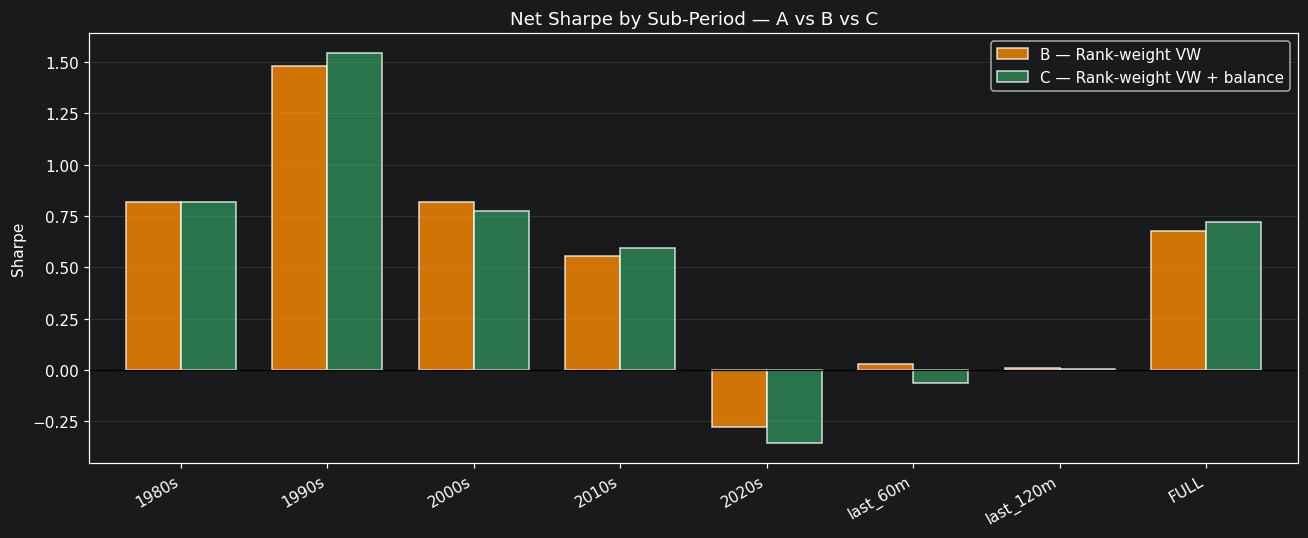

In [65]:
# Side-by-side sub-period Sharpe comparison
sub_sharpes = {}
for cfg, df in dfs.items():
    label = CFGS[cfg][0]
    tbl = subperiod_table(df, col='net_qspread')
    sub_sharpes[label] = tbl['sharpe']

comparison = pd.DataFrame(sub_sharpes)
print('Net Sharpe by Sub-Period:')
print(comparison.to_string())

# Bar chart
ax = comparison.plot(kind='bar', figsize=(12, 5), width=0.75,
                     color=[CFGS[c][1] for c in dfs],
                     alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Net Sharpe by Sub-Period — A vs B vs C')
ax.set_ylabel('Sharpe')
ax.set_xlabel('')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2, axis='y')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 14. Decision Summary

**Interpretation guide**

| Question | Where to look |
|---|---|
| Which construction wins? | Compare `last_120m` (last 10y) Sharpe — out-of-sample is more honest than full-sample |
| Did rank-weighting add value? | B vs A Sharpe — same universe, just weights |
| Did leg-balancing add value? | C vs B Sharpe — identical construction except `balance_legs` |
| Is the TC cost worth it? | Compare TC Drag across configs; check if higher TO in B/C is offset by higher gross Sharpe |
| Is the model signal still alive? | `last_60m` mean IC and ICIR |


In [66]:
# Quick decision printout
print('\nVERDICT SUMMARY')
print('=' * 60)
for cfg, df in dfs.items():
    label = CFGS[cfg][0]
    tbl = subperiod_table(df, col='net_qspread')
    full_sr   = tbl.loc['FULL',      'sharpe']
    last10_sr = tbl.loc['last_120m', 'sharpe']
    last5_sr  = tbl.loc['last_60m',  'sharpe']
    full_ret  = tbl.loc['FULL',      'ann_ret']
    print(f'\n  {label}')
    print(f'    Full-sample  net SR : {full_sr:>7.3f}   ann ret: {full_ret:.2%}')
    print(f'    Last 10y     net SR : {last10_sr:>7.3f}')
    print(f'    Last  5y     net SR : {last5_sr:>7.3f}')

print()
print('  --> Prefer the config with the BEST LAST-10-YEAR Sharpe.')
print('  --> If A wins out-of-sample, the upgrades did not help — keep it simple.')
print('=' * 60)


VERDICT SUMMARY

  B — Rank-weight VW
    Full-sample  net SR :   0.675   ann ret: 12.04%
    Last 10y     net SR :   0.011
    Last  5y     net SR :   0.030

  C — Rank-weight VW + balance
    Full-sample  net SR :   0.722   ann ret: 10.21%
    Last 10y     net SR :   0.007
    Last  5y     net SR :  -0.064

  --> Prefer the config with the BEST LAST-10-YEAR Sharpe.
  --> If A wins out-of-sample, the upgrades did not help — keep it simple.
